<a href="https://colab.research.google.com/github/Gr1lledChee5e/TimeSeriesForcastingPortfolio/blob/main/STL_and_Nixtlaverse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Packages

In [ ]:
#!pip install pmdarima

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmdarima import auto_arima

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.exponential_smoothing.ets import ETSModel


from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.forecasting.stl import STLForecast

import warnings

warnings.filterwarnings(
     'ignore',
     category=UserWarning,
     module='statsmodels'
)


# Helper Functions

## accuracy

In [ ]:
def accuracy(y_observed, y_forecast):
  mae = np.mean(np.abs(y_observed - y_forecast))
  rmse = np.sqrt(np.mean((y_observed - y_forecast)**2))
  mape = np.mean(np.abs((y_observed - y_forecast) / y_observed)) * 100
  return {'MAE': mae, 'RMSE': rmse, 'MAPE%': mape}

## STL Components Plot

In [ ]:
def stl_plot(stl_model):
    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    # Original Series
    axes[0].plot(stl_model.observed, label='Original Series', color='grey')
    axes[0].set_ylabel('Observed')
    axes[0].legend(loc='upper left')

    # Trend Component
    axes[1].plot(stl_model.trend, label='Trend', color='grey')
    axes[1].set_ylabel('Trend')
    axes[1].legend(loc='upper left')

    # Seasonal Component
    axes[2].plot(stl_model.seasonal, label='Seasonal', color='grey')
    axes[2].set_ylabel('Seasonal')
    axes[2].legend(loc='upper left')

    # Residual Component
    axes[3].plot(stl_model.resid, label='Residual', color='grey')
    axes[3].set_ylabel('Residual')
    axes[3].legend(loc='upper left')

    plt.xlabel('Date')
    plt.suptitle('STL Decomposition Components', y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()


## acf_plots

In [ ]:
def acf_plots(y, lags=20, pacf_method="ywm"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    y = y.dropna()
    plot_acf(y, lags=lags, ax=axes[0])
    plot_pacf(y, lags=lags,  method=pacf_method, ax=axes[1])
    axes[0].set_title("ACF")
    axes[1].set_title("PACF")
    axes[0].set_xlim((0, lags))
    axes[1].set_xlim((0, lags))
    plt.tight_layout()
    return fig.show()

## eacf_plot

Extended Autocorrelation Function plot. Use this matrix of "x" and "o" to identify suitable values for p and q when both AR and MA terms are in your model.

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf

def eacf_plot(y, max_p=4, max_q=4):
    y = y.dropna()
    y = np.asarray(y)
    n = len(y)
    crit = 2 / np.sqrt(n)  # approx 95% CI

    table = np.empty((max_p + 1, max_q + 1), dtype=object)

    for p in range(max_p + 1):
        if p == 0:
            resid = y - y.mean()
        else:
            ar = AutoReg(y, lags=p, old_names=False).fit()
            resid = ar.resid

        r = acf(resid, nlags=max_q, fft=False)

        for q in range(max_q + 1):
            table[p, q] = "o" if abs(r[q]) < crit else "x"

    return table

## lb_plot

Ljung-Box P-Values

Used to check residuals for remaining autocorrelation. Plot returns p-values for testing for autocorrelation up to each lag. We want to see high p-values, which would indicate that there is no remaining autocorrelation in the series (because we captured it in our model).



In [ ]:
def lb_plot(model_fit):
  results = acorr_ljungbox(model_fit.resid)
  lags = results.index
  plt.figure(figsize=(12,6))
  plt.scatter(x=lags, y=results['lb_pvalue'])
  plt.axhline(y=0.05, color='red', linestyle='--')
  plt.ylim(0, 1)
  plt.show()

## ts_cv

In [ ]:
def ts_cv(
    y: pd.Series,
    h: int=1,
    initial: int=24,
    step: int=1,
    forecast_function: callable=None
):

    n = len(y)

    rows = []
    fold = 0

    for train_end in range(initial, n - h + 1, step):
        fold += 1
        y_train = y.iloc[:train_end]
        y_test  = y.iloc[train_end:train_end + h]

        # Forecast next h periods
        y_hat = forecast_function(y_train, h)

        # Align with actual y_test (should match if freq is consistent)
        y_hat = y_hat.reindex(y_test.index)
        fold_df = pd.DataFrame({
            "fold": fold,
            "cutoff": y_train.index[-1],
            "h": np.arange(1, h + 1),
            "y": y_test.values,
            "y_hat": y_hat.values
        }, index=y_test.index)

        rows.append(fold_df)

    cv_df = pd.concat(rows).sort_index()

    # Overall metrics
    err = cv_df["y"] - cv_df["y_hat"]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))

    denom = np.where(cv_df["y"].values == 0, np.nan, np.abs(cv_df["y"].values))
    mape = float(np.nanmean(np.abs(err.values) / denom) * 100)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE%": mape}
    return metrics

# ARIMA, ETS, STL+ARIMA, STL+ETS??

For each of the datasets below, compare the four approaches above to forecasting.

+ Specify + Fit (+ diagnostics)
+ Plot fitted values (does model look ok?)
+ Train/Test
+ TS Cross Validation
+ Who wins?

For STL+ARIMA, consider auto_arima() on deseasonalized series for speed today.

**NOTE:** I did not include datasets with additional predictor variables, but if you had those you could do ARIMAX / STL + ARIMAX, you would not do ETS.

## Data 0 - Auto Sales (Last Class)

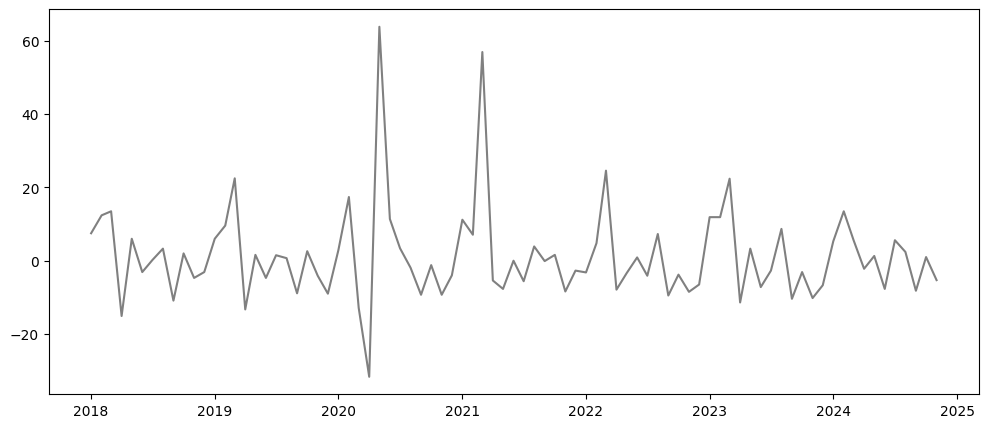

In [ ]:
# Percent Change in US Auto Sales
auto_sales = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=MRTSMPCSM44112USN&scale=left&cosd=1992-02-01&coed=2024-11-01&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2025-02-08&revision_date=2025-02-08&nd=1992-02-01')


auto_sales['observation_date'] = pd.to_datetime(auto_sales['observation_date'])
auto_sales = auto_sales.set_index('observation_date')

y = auto_sales['MRTSMPCSM44112USN'].asfreq('MS')
y = y.loc['2018':]

# NOTE: If "outliers" are replaced:  1) Seasonal Means 2) ETS, no gain from STL (but no harm either)
#y.loc['2020-04-01'] = -12.428571
#y.loc['2020-05-01'] = 9.285714
#y.loc['2021-03-01'] = 18.957143

plt.figure(figsize=(12, 5))
plt.plot(y, color='grey')
plt.show()

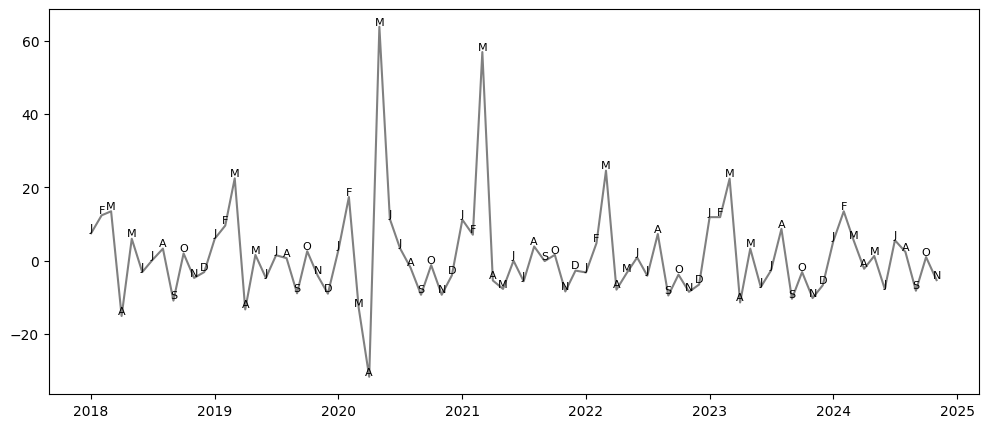

In [ ]:
# I put this here just to confirm the seasonality.

plt.figure(figsize=(12, 5))
plt.plot(y, color='grey')

# Add first letter of month at each point
for dt, val in y.items():
    month_letter = dt.strftime('%b')[0]   # e.g., Jan → J
    plt.text(dt, val, month_letter,
             ha='center', va='bottom',
             fontsize=8)

plt.show()

In [ ]:
# ARIMA
m_arima = ARIMA(y, order=(2, 1, 1), seasonal_order=(2, 1, 0, 12)).fit()

In [ ]:
# ETS
m_ets = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=12).fit()

In [ ]:
# STL + ARIMA/ETS

stl_decomp = STL(y, period=12, seasonal=13).fit()
y_ds = y - stl_decomp.seasonal

m_stl_arima = STLForecast(
    y,
    ARIMA,
    period=12,
    seasonal=13,
    model_kwargs={"order": (0, 0, 0), "seasonal_order":(2, 0, 0, 12), "trend":'t'}
).fit()

m_stl_ets = STLForecast(
    y,
    ETSModel,
    period=12,
    seasonal=13,
    model_kwargs={"error": "add", "trend": "add", "seasonal": 'add', "seasonal_periods":12}
).fit()

In [ ]:
def arima_fc(y, h):
  y_hat = ARIMA(y, order=(2, 1, 1), seasonal_order=(2, 1, 0, 12)).fit().forecast(h)
  return y_hat

def ets_fc(y, h):
  y_hat = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=12).fit().forecast(h)
  return y_hat

def stl_arima_fc(y, h):
  y_hat = STLForecast(y, ARIMA, period=12, seasonal=13, model_kwargs={"order": (0, 0, 0), "seasonal_order":(2, 0, 0, 12), "trend":'t'}).fit().forecast(h)
  return y_hat

def stl_ets_fc(y, h):
  y_hat = STLForecast(y, ETSModel, period=12, seasonal=13, model_kwargs={"error": "add", "trend": "add", "seasonal": 'add', "seasonal_periods":12}).fit().forecast(h)
  return y_hat

def mean_fc(y, h):
  y_hat = ARIMA(y, order=(0, 0, 0), trend='c').fit().forecast(h)
  return y_hat

month_means = y.groupby(y.index.month).mean()
def seasonal_mean_fc(y, h):
  future_idx = pd.date_range(start=y.index[-1] + pd.tseries.frequencies.to_offset('1MS'), periods=h, freq='MS')
  y_hat = pd.Series([month_means[m] for m in future_idx.month], index=future_idx, name="seasonal_mean_fc")
  return y_hat

In [ ]:
print("ARIMA Forecasts")
ts_cv(y, h=1, initial=48, step=2, forecast_function=arima_fc)

ARIMA Forecasts


{'MAE': 6.672939262903838,
 'RMSE': 9.47565782025269,
 'MAPE%': 101.34690898628864}

In [ ]:
print("ETS Forecasts")
ts_cv(y, h=1, initial=48, step=2, forecast_function=ets_fc)

ETS Forecasts


{'MAE': 4.6878133859075, 'RMSE': 6.227067306879692, 'MAPE%': 73.30874149787783}

In [ ]:
print("STL+ARIMA Forecasts")
ts_cv(y, h=1, initial=48, step=2, forecast_function=stl_arima_fc)

STL+ARIMA Forecasts


{'MAE': 5.913821626602086,
 'RMSE': 7.68401549765234,
 'MAPE%': 102.11779132788934}

In [ ]:
print("STL+ETS Forecasts")
ts_cv(y, h=1, initial=48, step=2, forecast_function=stl_ets_fc)

STL+ETS Forecasts


{'MAE': 5.907819584678932,
 'RMSE': 7.975858438821973,
 'MAPE%': 105.58009568250854}

In [ ]:
print("Mean Forecasts")
ts_cv(y, h=1, initial=48, step=2, forecast_function=mean_fc)

Mean Forecasts


{'MAE': 8.200049031452068,
 'RMSE': 10.216575002780399,
 'MAPE%': 101.29841200435324}

In [ ]:
print("Seasonal Mean Forecasts")
ts_cv(y, h=1, initial=48, step=2, forecast_function=seasonal_mean_fc)

Seasonal Mean Forecasts


{'MAE': 4.021655325396825,
 'RMSE': 5.20085825250282,
 'MAPE%': 66.22666890510169}

In [ ]:
print('ARIMA Improvement: ',  str(round( ( (166.95063333350865-260.5528404648014)/260.5528404648014)*100, 2))+'%'  )
print('ETS Improvement: ', str(round( ( (128.77164235934166-161.05050768275407)/161.05050768275407)*100, 2))+'%' )


ARIMA Improvement:  -35.92%
ETS Improvement:  -20.04%


### Takeaways from Data 0

+ None of these models did great, in fact, the best forecast came from the mean forecast.
+ Due to the outliers, the seasonal means forecast did worse than the mean forecast, but if you replace those outliers the seasonal means win.
+ ETS did better than ARIMA here
+ STL + ETS did better than ETS alone (20% decrease in MAPE)
+ STL + ARIMA did better than ARIMA alone (35% decrease in MAPE)

STL is known to be more robust to outliers, and this series has some. Thus, no surprise to see STL improve the performance of both ETS and ARIMA.


## Data 1- Air Passengers Data

Transformation or not?

+ ARIMA - Must transform to stabilize variance
+ ETS - Option to transform or include multiplicative seasonal terms
+ STL - Can capture evolving seasonality, though sometimes a transformation may perform better.
  + Seasonality increases proportional to scale $\rightarrow$ transform
  + Seasonality changes shape or otherwise evolves over time $\rightarrow$ STL inherently handles without need of transformations



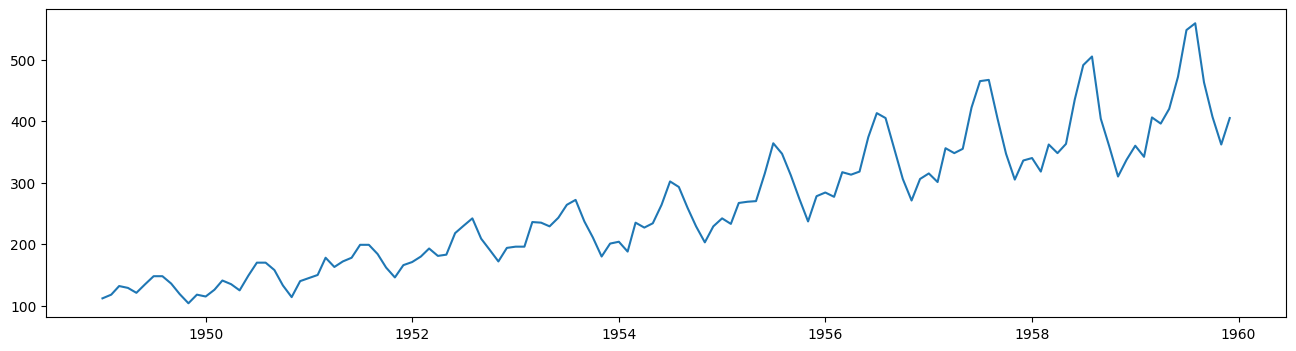

In [ ]:
airpassengers = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/fppy/AirPassengers.csv')

airpassengers['ds'] = pd.to_datetime(airpassengers['ds'])
y = airpassengers.set_index('ds')['y']

y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

plt.figure(figsize=(16, 4))
plt.plot(y_train)
plt.show()

### ARIMA

Increasing seasonality $\rightarrow$ transformation

In [ ]:
# ARIMA
#   ME: ARIMA(np.log(y_train), order=(1, 1, 0), seasonal_order=(0, 1, 1, 12)).fit()
#   AA: Seems worse...
m_arima = ARIMA(np.log(y_train), order=(1, 1, 0), seasonal_order=(0, 1, 1, 12)).fit()

### ETS

Increasing seasonality:

1. No Transformation + Multiplicative Seasonality
2. Transformation + Additive Seasonality

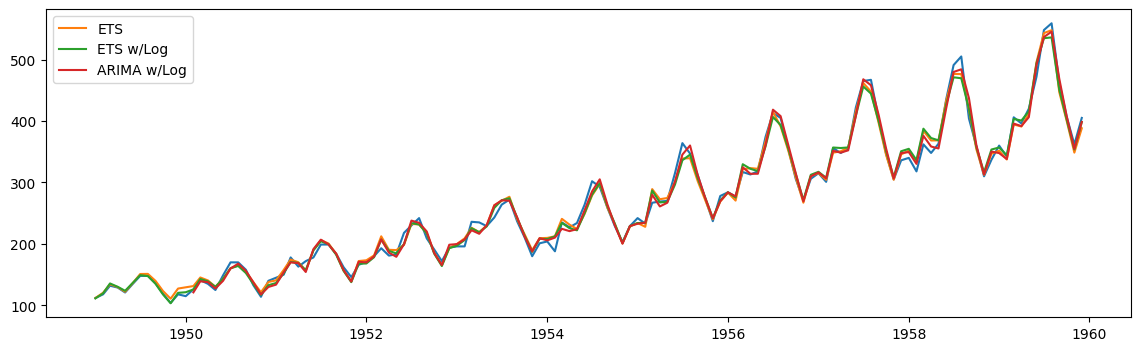

In [ ]:
# ETS

m_ets = ETSModel(y_train, error='add', trend='add', seasonal='mul', seasonal_periods=12).fit()

# m_ets_log =
m_ets_log = ETSModel(np.log(y_train), error='add', trend='add', seasonal='add', seasonal_periods=12).fit()


# Add fitted values
plt.figure(figsize=(14,4))
plt.plot(y_train)
plt.plot(m_ets.fittedvalues, label='ETS')
plt.plot( np.exp(m_ets_log.fittedvalues), label='ETS w/Log')
plt.plot( np.exp(m_arima.fittedvalues[13:]), label='ARIMA w/Log')
plt.legend()
plt.show()

### STL Models

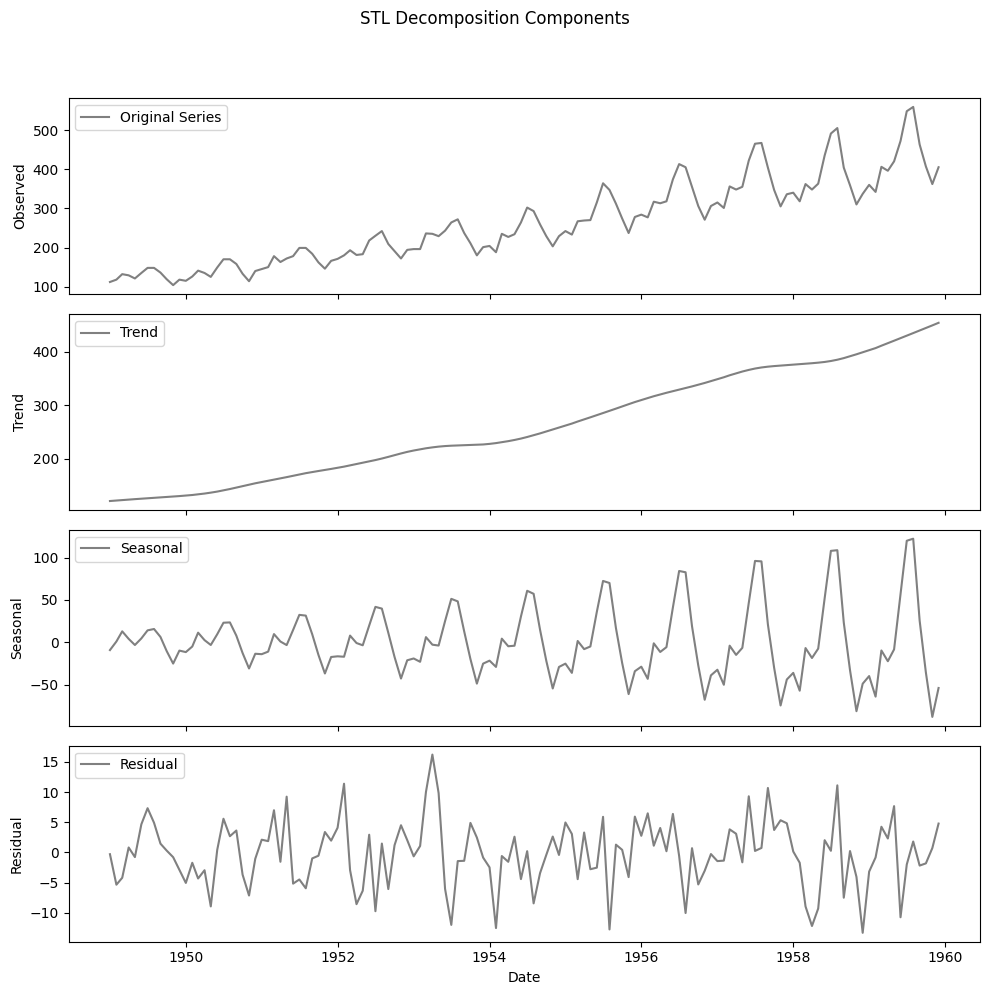

In [ ]:
# STL
#  ARIMA(1, 1, 0)
#  ETS(AAN) -> Seasonal:None because STL handles the seasonality

# period too small -> trend picks up seasonality
# seasonal too small -> seasonality leaks into residual
# period too big -> trend leaks into seasonal component
# trying to find balance
stl_decomp = STL(y_train, period=12, seasonal=13).fit()
stl_plot(stl_decomp)
#y_ds = y_train - stl_decomp.seasonal

m_stl_arima = STLForecast(y_train, ARIMA, period=12, seasonal=13, model_kwargs={'order':(1, 1, 0), 'trend':'t'}).fit()
m_stl_ets = STLForecast(y_train, ETSModel, period=12, seasonal=13, model_kwargs={'error':'add', 'trend':'add', 'seasonal':None}).fit()

In [ ]:
# Forecast and Plot over Test Period
fc_arima = np.exp(m_arima.forecast(12))
fc_ets = m_ets.forecast(12)
fc_ets_log = np.exp(m_ets_log.forecast(12))
fc_stl_arima = m_stl_arima.forecast(12)
fc_stl_ets = m_stl_ets.forecast(12)

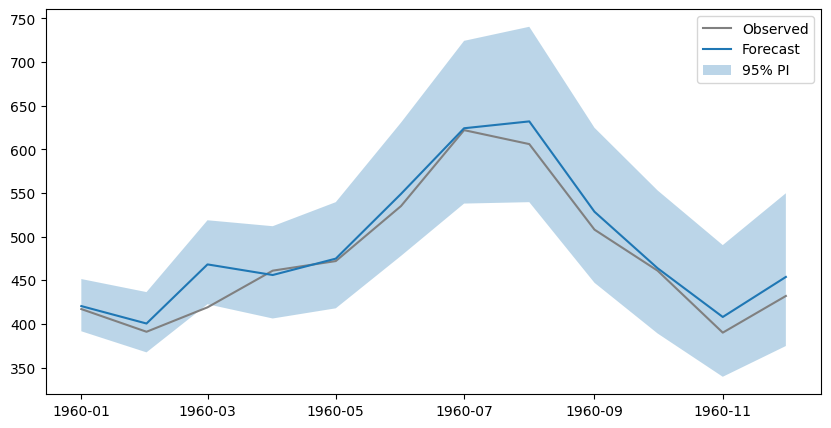

In [ ]:
# Want Prediction Intervals? Use .get_forecast() instead of .forecast()
forecast_arima_model = m_arima.get_forecast(12)
fc_arima = np.exp(forecast_arima_model.predicted_mean)
fc_arima_interval = np.exp(forecast_arima_model.conf_int(.05))

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Observed", color="grey")
plt.plot(fc_arima, label="Forecast")
plt.fill_between(
    fc_arima_interval.index,
    fc_arima_interval.iloc[:,0],
    fc_arima_interval.iloc[:,1],
    alpha=0.3,
    label="95% PI"
)
plt.legend()
plt.show()

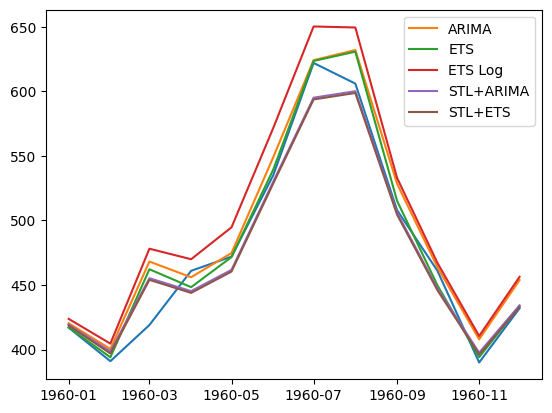

In [ ]:
plt.plot(y_test)
plt.plot(fc_arima, label='ARIMA')
plt.plot(fc_ets, label='ETS')
plt.plot(fc_ets_log, label='ETS Log')
plt.plot(fc_stl_arima, label='STL+ARIMA')
plt.plot(fc_stl_ets, label='STL+ETS')
plt.legend()
plt.show()

In [ ]:
print('ARIMA:',  accuracy(y_test, fc_arima))
print('ETS:', accuracy(y_test, fc_ets))
print('ETS w/LOG:', accuracy(y_test, fc_ets_log))
print('STL+ARIMA:', accuracy(y_test, fc_stl_arima))
print('STL+ETS:', accuracy(y_test, fc_stl_ets))

ARIMA: {'MAE': np.float64(14.58118627773525), 'RMSE': np.float64(19.689987288546494), 'MAPE%': np.float64(3.181783637502125)}
ETS: {'MAE': np.float64(9.528802582180083), 'RMSE': np.float64(15.459953752396574), 'MAPE%': np.float64(2.033597993310563)}
ETS w/LOG: {'MAE': np.float64(24.619133474304977), 'RMSE': np.float64(28.90002921140777), 'MAPE%': np.float64(5.138436622152651)}
STL+ARIMA: {'MAE': np.float64(11.292872877445339), 'RMSE': np.float64(15.182409988494936), 'MAPE%': np.float64(2.400319902897538)}
STL+ETS: {'MAE': np.float64(11.562626942847809), 'RMSE': np.float64(15.434684083677821), 'MAPE%': np.float64(2.4254260904950797)}


In [ ]:
def arima_fc(y_train, h):
  y_hat = np.exp(ARIMA(np.log(y_train),  order=(1, 1, 0), seasonal_order = (0, 1, 1, 12)).fit().forecast(h))
  return y_hat

def ets_fc(y_train, h):
  y_hat = ETSModel(y_train, error='add', trend='add', seasonal='mul').fit().forecast(h)
  return y_hat

def ets_log_fc(y_train, h):
  y_hat = np.exp(ETSModel(np.log(y_train), error='add', trend='add', seasonal='add').fit().forecast(h))
  return y_hat

def stl_arima_fc(y_train, h):
  y_hat = STLForecast(y_train, ARIMA, period=12, seasonal=13, model_kwargs={"order": (0, 1, 1), "trend": 't'}).fit().forecast(h)
  return y_hat

def stl_ets_fc(y_train, h):
  y_hat = STLForecast(y_train, ETSModel, period=12, seasonal=13, model_kwargs={"error": "add", "trend": "add", "seasonal": None}).fit().forecast(h)
  return y_hat

In [ ]:
print('ARIMA')
ts_cv(y, h=6, initial=60, step=4, forecast_function=arima_fc)

{'MAE': 12.922549128005551,
 'RMSE': 16.855253989063982,
 'MAPE%': 3.682756593991058}

In [ ]:
print("ETS")
ts_cv(y, h=6, initial=60, step=4, forecast_function=ets_fc)

{'MAE': 13.491318836389363,
 'RMSE': 17.71647027218072,
 'MAPE%': 3.8157127073952046}

In [ ]:
print("ETS w/Log")
ts_cv(y, h=6, initial=60, step=4, forecast_function=ets_log_fc)

{'MAE': 19.12954215071573,
 'RMSE': 24.519778641257382,
 'MAPE%': 5.398811782007646}

In [ ]:
print("STL + ARIMA")
ts_cv(y, h=6, initial=60, step=4, forecast_function=stl_arima_fc)


{'MAE': 12.709361731726707,
 'RMSE': 15.802851135319967,
 'MAPE%': 3.6931530804697776}

In [ ]:
print("STL + ETS")
ts_cv(y, h=6, initial=60, step=4, forecast_function=stl_ets_fc)

{'MAE': 13.030707321519825,
 'RMSE': 16.177159491874804,
 'MAPE%': 3.7957297544154187}

### Takeaways from Data 1

+ Performance similar across models, though ETS w/ log transformation generally worst among them
+ ARIMA, ETS, STL+ARIMA, STL+ETS all similar performance, *SLIGHT* edge to ARIMA in cross validation

## Data 3 - Trade Data

I will model the trade series twice below: once using **statsmodels** and once using **statsforecast**.

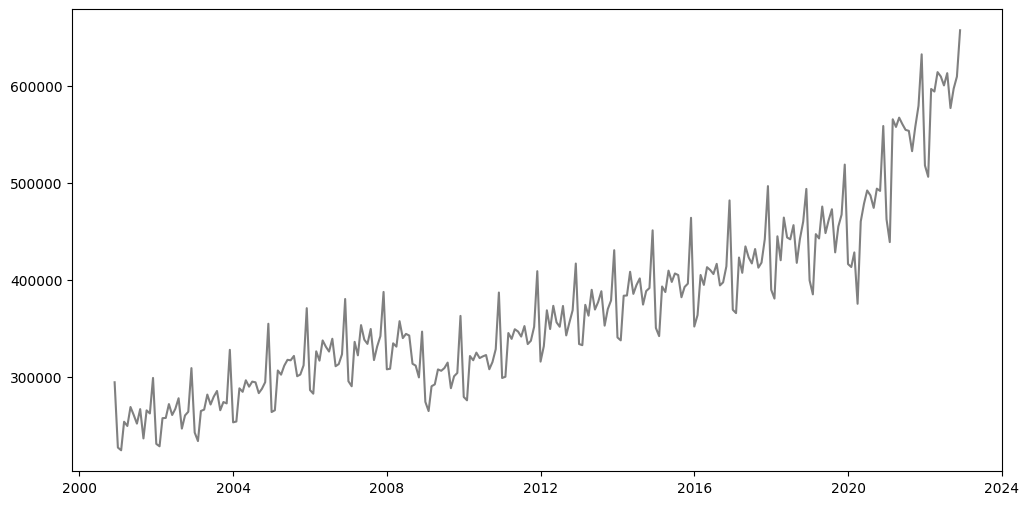

In [ ]:
fed_data = pd.read_csv('https://dxl-datasets.s3.amazonaws.com/data/fed_data.csv')
fed_data['date'] = pd.to_datetime(fed_data['date'])
fed_data = fed_data.set_index('date')
y = fed_data['trade'].asfreq('MS')

plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.show()

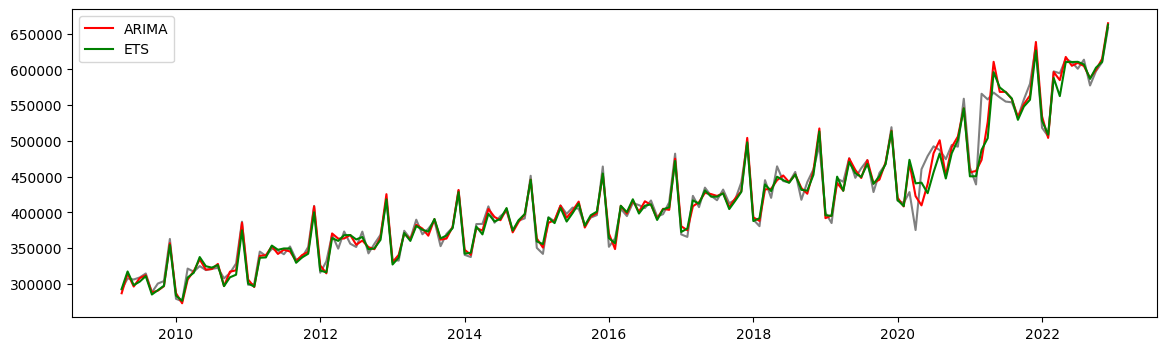

In [ ]:
# ME: ARIMA(1, 1, 1)x(0, 1, 2)
# Auto Arima:
m_arima = ARIMA(y, order=(1, 1, 1), seasonal_order=(0, 1, 2, 12)).fit()
m_ets = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=12).fit()

plt.figure(figsize=(14,4))
plt.plot(y[100:], color='grey')
plt.plot(m_arima.fittedvalues[100:], color='red', label='ARIMA')
plt.plot(m_ets.fittedvalues[100:], color='green', label='ETS')
plt.legend()
plt.show()

# Nixtlaverse / StatsForecast

In [ ]:
#!pip install statsforecast

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTBATS, ARIMA# note that this ARIMA is different from statsmodels

from utilsforecast.losses import mse, mae, mape, smape
from utilsforecast.evaluation import evaluate
from utilsforecast.plotting import plot_series

In [ ]:
# SWITCH TO NIXTLAVERSE
fed_data = pd.read_csv('https://dxl-datasets.s3.amazonaws.com/data/fed_data.csv')

# Requires columns: ds | y | unique_id

trade_data = fed_data.copy()

# 1) Grab columns I want
trade_data = trade_data[['date', 'trade']]

# 2) Fix date variables
trade_data['date'] = pd.to_datetime(trade_data['date'])

# 3) Add a unique_id column
trade_data['unique_id'] = 'Trade'

# 4) Rename to match required format
trade_data = trade_data.rename(columns={'date': 'ds', 'trade': 'y'})

trade_data.head()


,ds,y,unique_id
0,2000-12-01,294197,Trade
1,2001-01-01,226791,Trade
2,2001-02-01,223971,Trade
3,2001-03-01,253439,Trade
4,2001-04-01,249062,Trade


In [ ]:
# Models

# https://nixtlaverse.nixtla.io/statsforecast/index.html#automatic-forecasting
# Add another?


# I am going to compare 4 models here:
#   AutoARIMA, AutoETS
#   ARIMA (that I built above, to see how I compare with AutoARIMA)
#   AutoTBATS (I don't even know this one, but I saw it in the documentation and thought I'd give it a try to highlight how easy it is to test models in statsforecast)
#      T = Trigonometric
#      B = BoxCox
#      A = ARMA
#      T = Trend
#      S = Seasonal

# For the AutoXXX Models, just pass the season length, for ARIMA pass in your model parameters
models = [
    AutoARIMA(season_length=12),
    ARIMA(order=(1, 1, 1), seasonal_order=(0, 1, 2), season_length=12),
    AutoETS(season_length=12),
    AutoTBATS(season_length=12)
]

In [ ]:
# Forecast object
sf = StatsForecast(
    models,
    freq='MS'
)

In [ ]:
fcst = sf.forecast(df=trade_data, h=12)
fcst.head()

,unique_id,ds,AutoARIMA,ARIMA,AutoETS,AutoTBATS
0,Trade,2023-01-01,558135.4375,556813.1875,554334.8125,541302.3125
1,Trade,2023-02-01,548526.6250,548067.8125,545811.2500,525688.3125
2,Trade,2023-03-01,621413.6875,620727.0000,618071.0625,611577.5000
3,Trade,2023-04-01,607284.1875,607596.8125,598822.8750,586088.1875
4,Trade,2023-05-01,638230.3125,637794.5625,626771.8125,636598.1250


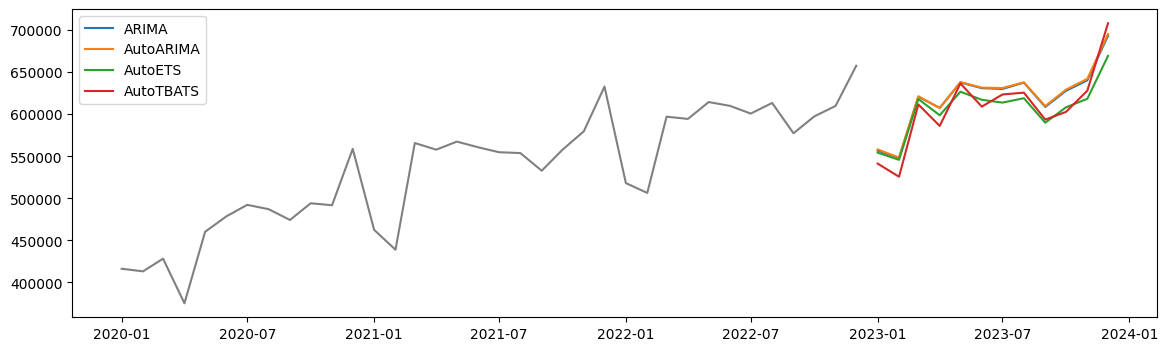

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(trade_data['ds'][-36:], trade_data['y'][-36:], color='grey')
plt.plot(fcst['ds'], fcst['ARIMA'], label='ARIMA')
plt.plot(fcst['ds'], fcst['AutoARIMA'], label='AutoARIMA')
plt.plot(fcst['ds'], fcst['AutoETS'], label='AutoETS')
plt.plot(fcst['ds'], fcst['AutoTBATS'], label='AutoTBATS')
plt.legend()
plt.show()

In [ ]:
# Cross Validation
#    NOTE: Cross validation can be slow here if you are using 1) many models or 2) AutoXXX models, so set CV parameters wisely!
cv = sf.cross_validation(
    df=trade_data,
    h=6,
    step_size=12,
    n_windows = 5
)

In [ ]:
# Evaluate per model across all cutoffs/horizons
scores = evaluate(
    df=cv,
    metrics=[mae, mse, mape, smape],
    models=["ARIMA", "AutoARIMA", "AutoETS", "AutoTBATS"]
)

metrics = scores.groupby('metric')[['ARIMA', 'AutoARIMA', 'AutoETS', 'AutoTBATS']].mean().reset_index()
metrics.head()

,metric,ARIMA,AutoARIMA,AutoETS,AutoTBATS
0,mae,1.219899e+04,1.550817e+04,1.377695e+04,1.668972e+04
1,mape,2.361387e-02,3.011062e-02,2.723678e-02,3.214545e-02
2,mse,2.553623e+08,4.221149e+08,3.804515e+08,4.803669e+08
3,smape,1.194598e-02,1.535299e-02,1.397198e-02,1.633717e-02


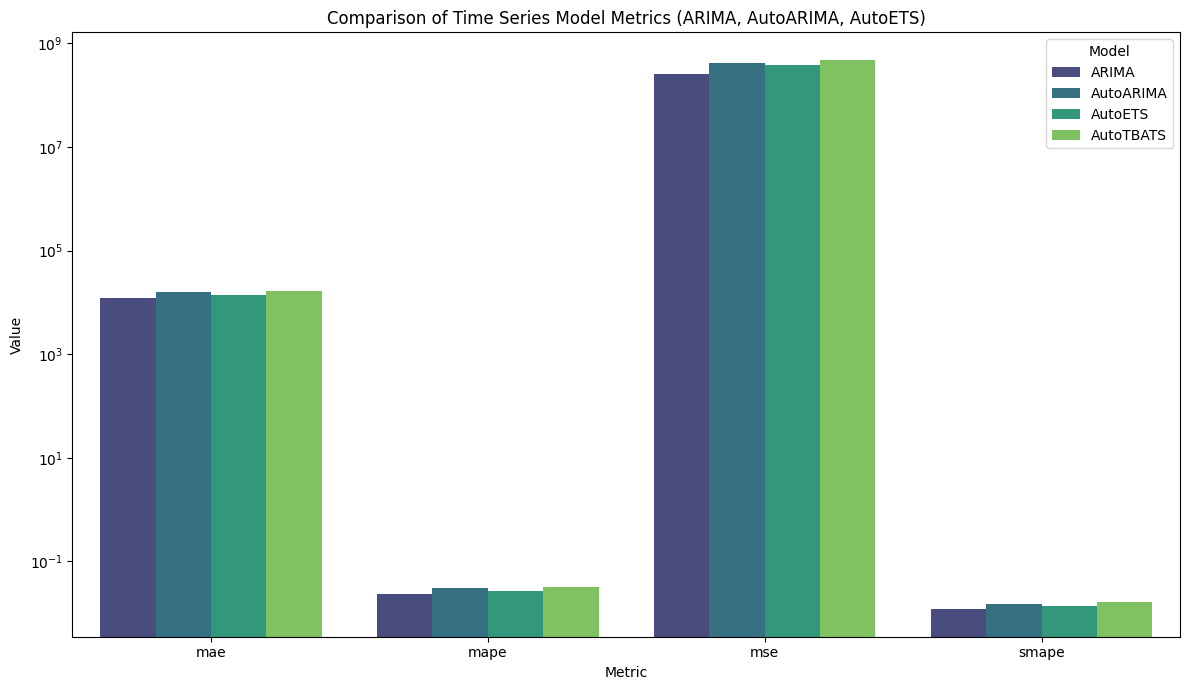

In [ ]:
# Reshape the DataFrame from wide to long format for plotting
metrics_long = metrics.melt(id_vars='metric', var_name='model', value_name='value')

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='metric', y='value', hue='model', data=metrics_long, palette='viridis')

plt.title('Comparison of Time Series Model Metrics (ARIMA, AutoARIMA, AutoETS)')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.yscale('log') # Use a log scale for better visualization if values vary widely
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### Quick Takeaway

+ Quickly fit and cross validate 4 models using **statsforecast**
+ Note that ARIMA - the model we built using our own knowledge of model building - did better than the Auto models here (though admittedly that's not always the case).

## StatsForecast for "global" forecasting

In this example, we fit and forecast all series in the data at the same time. This is where Nixtla / **statsforecast** does great; "forecasting at scale".

In [ ]:
fed_data = pd.read_csv('https://dxl-datasets.s3.amazonaws.com/data/fed_data.csv')

# 1) Grab columns I want
fed_data = fed_data[['date', 'trade', 'dspi', 'jobs', 'inv']]

# 2) "Melt" the data to transpose from wide -> long
fed_data_long = fed_data.melt(id_vars='date', var_name='unique_id', value_name='y')

# 3) Rename as needed
fed_data_long.rename(columns={'date': 'ds'}, inplace=True)

# 4) Fix datetime var
fed_data_long['ds'] = pd.to_datetime(fed_data_long['ds'])


fed_data_long.head()

,ds,unique_id,y
0,2000-12-01,trade,294197.0
1,2001-01-01,trade,226791.0
2,2001-02-01,trade,223971.0
3,2001-03-01,trade,253439.0
4,2001-04-01,trade,249062.0


In [ ]:
models = [
    ARIMA(order=(1, 1, 1), seasonal_order=(0, 1, 2), season_length=12),
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
    AutoTBATS(season_length=12)
]

In [ ]:
# Forecast object
sf = StatsForecast(
    models,
    freq='MS'
)

In [ ]:
# Forecast
fcst = sf.forecast(df=fed_data_long, h=6)
fcst.head()

,unique_id,ds,ARIMA,AutoARIMA,AutoETS,AutoTBATS
0,dspi,2023-01-01,19334.073302,19002.071722,18989.814898,19035.133820
1,dspi,2023-02-01,19152.374335,19062.334680,19041.487437,19126.615804
2,dspi,2023-03-01,19758.809758,19019.869445,19093.159975,19215.165827
3,dspi,2023-04-01,19771.797055,19113.146980,19144.832514,19293.348438
4,dspi,2023-05-01,19552.113942,19157.597111,19196.505053,19356.516370


In [ ]:
# Cross Validation
cv = sf.cross_validation(
    df=fed_data_long,
    h=6,
    step_size=6,
    n_windows=5
)

In [ ]:
# Evaluate per model across all cutoffs/horizons
scores = evaluate(
    df=cv,
    metrics=[mae, mse, mape, smape],
    models=["ARIMA", "AutoARIMA", "AutoETS", "AutoTBATS"]
)

metrics = scores.groupby(['unique_id', 'metric'] )[['ARIMA', 'AutoARIMA', 'AutoETS', 'AutoTBATS']].mean().reset_index()

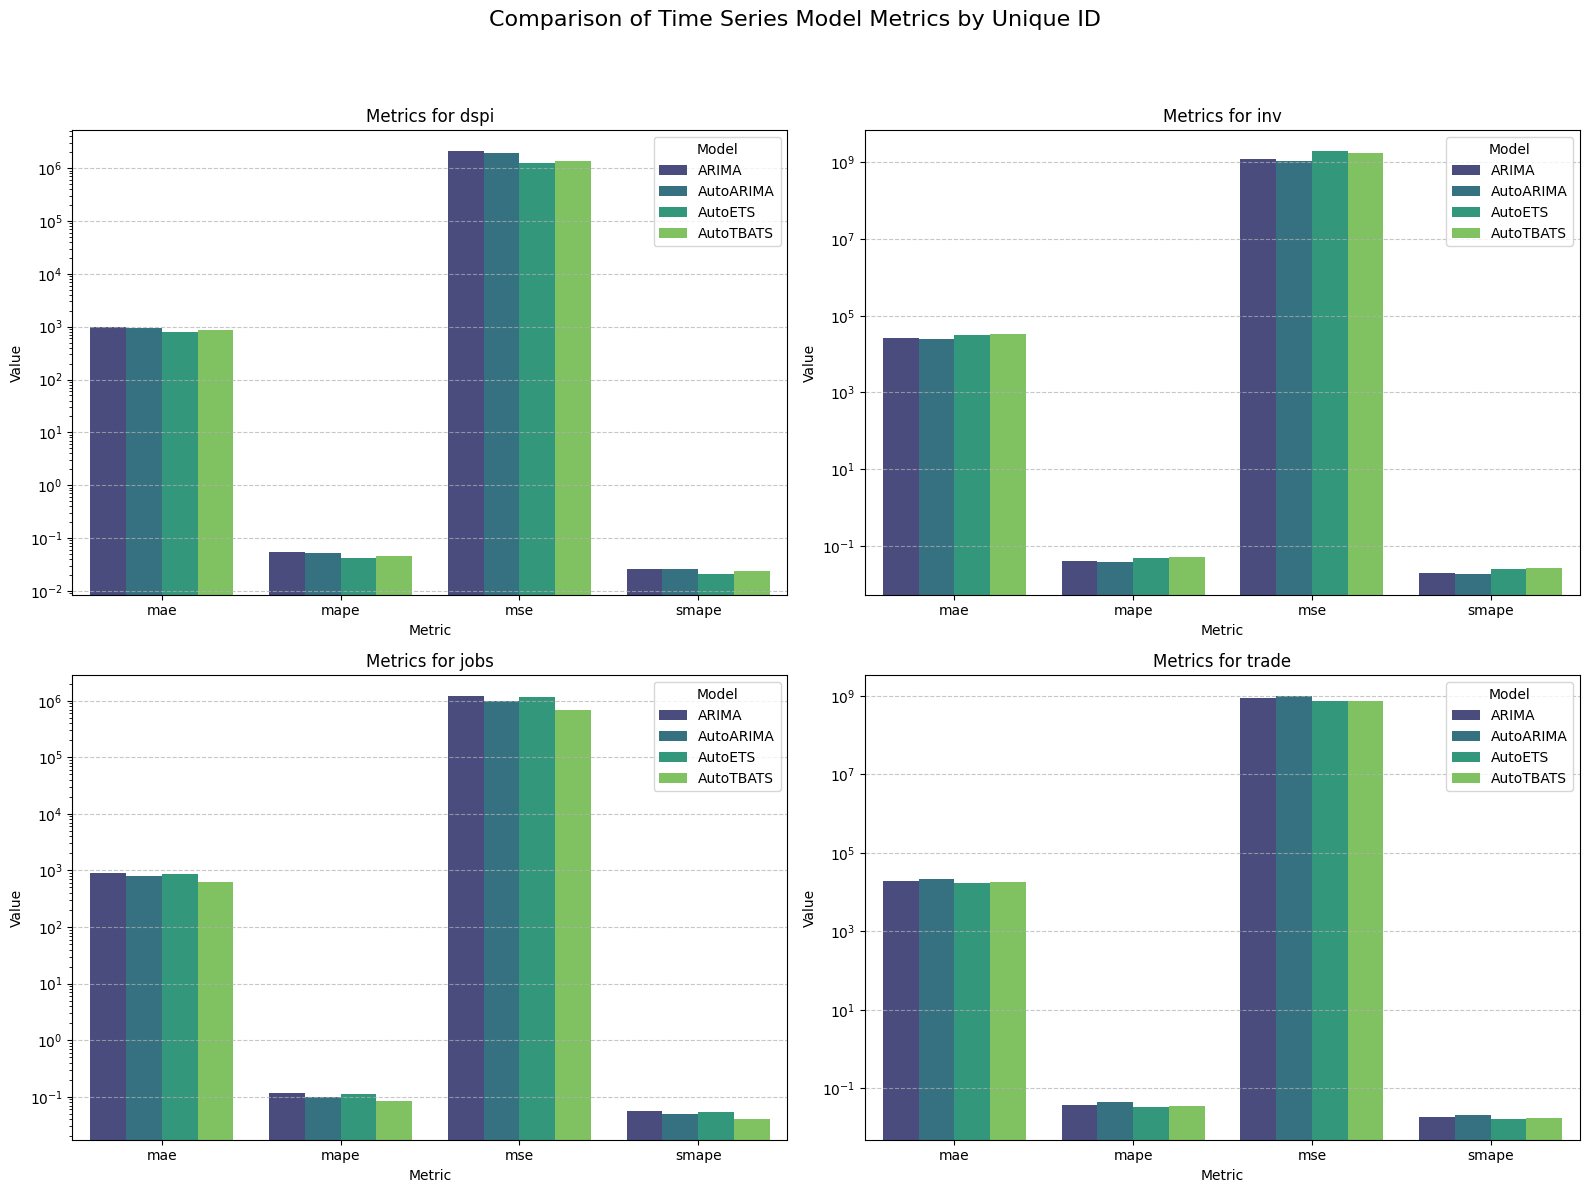

In [ ]:
# Reshape the DataFrame from wide to long format for plotting
metrics_long = metrics.melt(id_vars=['unique_id', 'metric'], var_name='model', value_name='value')

# Get unique unique_ids to create separate subplots
unique_ids = metrics_long['unique_id'].unique()
num_unique_ids = len(unique_ids)

# Determine grid size for subplots (e.g., 2 columns)
num_cols = 2
num_rows = (num_unique_ids + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 8, num_rows * 6)) # Adjust figure size dynamically

for i, uid in enumerate(unique_ids):
    plt.subplot(num_rows, num_cols, i + 1)
    subset_df = metrics_long[metrics_long['unique_id'] == uid]
    sns.barplot(x='metric', y='value', hue='model', data=subset_df, palette='viridis')
    plt.title(f'Metrics for {uid}')
    plt.xlabel('Metric')
    plt.ylabel('Value')
    plt.yscale('log') # Use a log scale for better visualization if values vary widely
    plt.legend(title='Model')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Comparison of Time Series Model Metrics by Unique ID', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

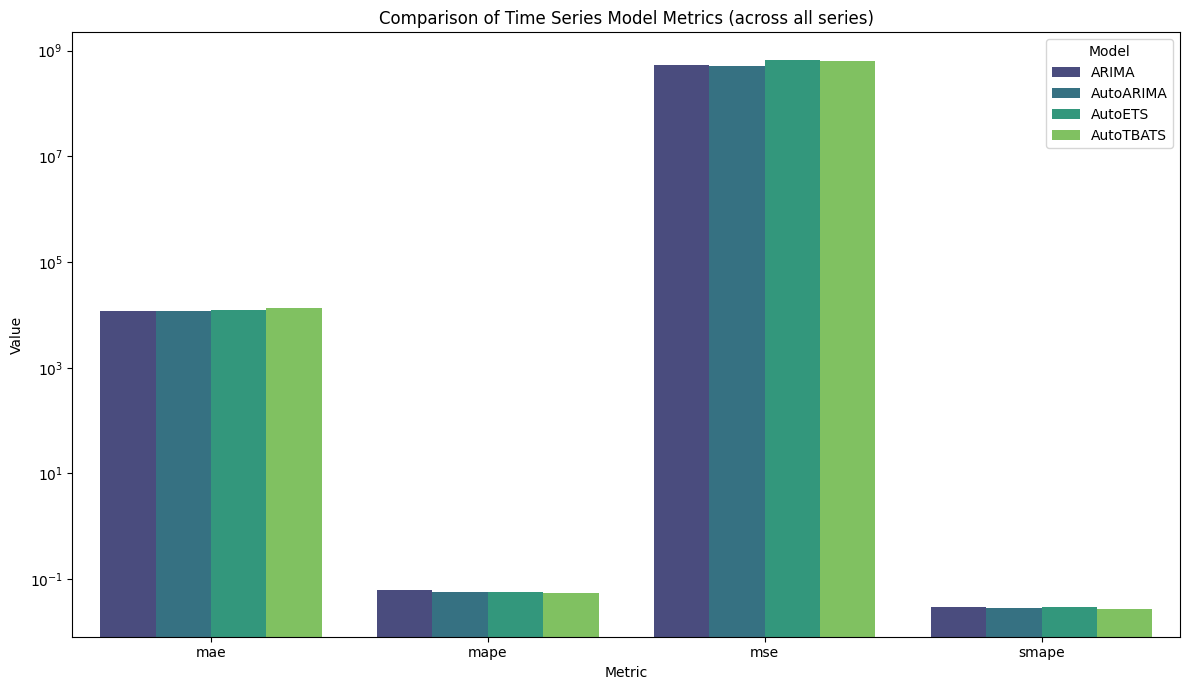

In [ ]:
# Average over unique_id to get "best model" for dataset

metrics = scores.groupby(['metric'] )[['ARIMA', 'AutoARIMA', 'AutoETS', 'AutoTBATS']].mean().reset_index()

# Reshape the DataFrame from wide to long format for plotting
metrics_long = metrics.melt(id_vars=['metric'], var_name='model', value_name='value')


# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='metric', y='value', hue='model', data=metrics_long, palette='viridis')

plt.title('Comparison of Time Series Model Metrics (across all series)')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.yscale('log') # Use a log scale for better visualization if values vary widely
plt.legend(title='Model')
plt.tight_layout()
plt.show()